<a href="https://colab.research.google.com/github/MahyarGarshasbi/3D-PMWPrecipitation/blob/main/Demo_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="crimson">Multi-spectral 3-D Encoding for Passive Microwave Extreme Precipitation Retrievals</font>

<font color="royalblue">**Mahyar Garshasbi, Ardeshir Ebtehaj, Buddha Subedi**</font>

Saint Anthony Falls Laboratory, Department of Civil, Environmental, and Geo-Engineering,

University of Minnesota

---

This notebook demonstrates the **3-D convolutional encoding** of GPM Microwave Imager (GMI)
observations for near-surface precipitation retrieval. The 13 GMI channels are treated as an
ordered spectral **depth** dimension, so a U-shaped encoder–decoder can learn joint
spatial–spectral structure rather than mixing channels as a stacked 2-D feature map.

<p align="center">
  <img src="https://raw.githubusercontent.com/MahyarGarshasbi/3D-PMWPrecipitation/main/Figures/Fig02.png" width="750">
</p>

### Notebook Contents
1. **Architecture** — 3-D U-Net and its 2-D counterpart
2. **Training**
3. **Orbital Inference** — 2-D vs 3-D retrievals against MRMS for three withheld storms

---

# <font color="darkgreen">⚙️ Setup & Data Download</font>

---

### 📦 Dependencies
Install packages for the Google Drive download, HDF5 reading, array handling, and map plotting.

### 📂 Sample Data
`gdown` pulls the `Implementation_2` folder, organized as:

**`Implementation_2/Orbits/`** — GMI Level-1B brightness temperatures (V08A) for three withheld storms

| File | Event |
|:-----|:------|
| `1B.GPM.GMI.TB2021.20241009-S182844-E200157.060279.V08A.hdf5` | Hurricane Milton — 9 Oct 2024, Florida (orbit 60279) |
| `1B.GPM.GMI.TB2021.20210829-S235714-E012947.042630.V08A.hdf5` | Hurricane Ida — 29 Aug 2021, Louisiana (orbit 42630) |
| `1B.GPM.GMI.TB2021.20240123-S223131-E000445.056266.V08A.hdf5` | Frontal squall line — 23 Jan 2024, south-central U.S. (orbit 56266) |

**`Implementation_2/Models/EVAL/`** — trained weights and input normalization statistics

| File | Description |
|:-----|:------------|
| `UNet3D-Rain.pth`      | 3-D encoding model weights |
| `UNet-Rain_Conv2D.pth` | 2-D baseline model weights |
| `mean.npy`, `std.npy`  | Per-channel TB mean and standard deviation for input normalization |

---

In [10]:
!pip install gdown -q

import gdown
import numpy as np
import os

# Download entire folder
folder_url = "https://drive.google.com/drive/folders/1rgSTbP-TKQ_DhTrjfO0ls44tgJPxfuaq?usp=sharing"
gdown.download_folder(folder_url, quiet=False, use_cookies=False)
!pip install cartopy

Retrieving folder contents


Retrieving folder 1EHClg5jQGZyjugYSIeOof_d2vj4uxovL Models
Retrieving folder 1M7XGx9YXhkNXW5jadmnZO9fOdzjEd25S EVAL
Processing file 1Ue8TxXCRbn9nplQ-v9tYvpoDYSidZeDb mean.npy
Processing file 1lhWcleQFqcV_iq4fNMnGh4ORe-9IjFSo std.npy
Processing file 1xWt2oYdl82xDLTJTZDiEZuqVNRWk9mho UNet-Rain_Conv2D.pth
Processing file 166E7gusg_VX0-54wx-nFEj3uWADXHy8g UNet3D-Rain.pth
Retrieving folder 1gb45VW9AmvA0FEFv9lrLvLGg-w7fAg9G Orbits
Processing file 1Xts1otO_RZBRt7-iBXmhUlPe8C2WaWOp 1B.GPM.GMI.TB2021.20210829-S235714-E012947.042630.V08A.hdf5
Processing file 1p7GGuR5PLX0-Ylh5XmgUja3BDMVObCyR 1B.GPM.GMI.TB2021.20240123-S223131-E000445.056266.V08A.hdf5
Processing file 1oyk8zcG5CUUNn8SVZT-zjQ1P-f33TwL_ 1B.GPM.GMI.TB2021.20241009-S182844-E200157.060279.V08A.hdf5


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Ue8TxXCRbn9nplQ-v9tYvpoDYSidZeDb
To: /content/Implementation_2/Implementation_2/Models/EVAL/mean.npy
100%|██████████| 180/180 [00:00<00:00, 616kB/s]
Downloading...
From: https://drive.google.com/uc?id=1lhWcleQFqcV_iq4fNMnGh4ORe-9IjFSo
To: /content/Implementation_2/Implementation_2/Models/EVAL/std.npy
100%|██████████| 180/180 [00:00<00:00, 703kB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1xWt2oYdl82xDLTJTZDiEZuqVNRWk9mho
From (redirected): https://drive.google.com/uc?id=1xWt2oYdl82xDLTJTZDiEZuqVNRWk9mho&confirm=t&uuid=cf1e3440-dcf6-4f97-b1ce-35dc81dbacd8
To: /content/Implementation_2/Implementation_2/Models/EVAL/UNet-Rain_Conv2D.pth
100%|██████████| 50.4M/50.4M [00:00<00:00, 100MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=166E7gusg_VX0-54wx-nFEj3uWADXHy8g
From (redirected): https://dr

# <font color="darkorange">🧊 3-D Spectral–Spatial Encoding</font>

---

The 13 GMI channels form an **ordered spectral depth** $D=13$, so the input is $(N,\,1,\,13,\,H,\,W)$. `DoubleConv3D` blocks slide a $3\times3\times3$ kernel jointly across frequency and space, learning locality across neighboring channels. `MaxPool3D(1,2,2)` downsamples space only and keeps depth intact. After the decoder, `SpectralCollapse` folds the depth with a $13\times1\times1$ convolution, and a $1\times1$ Conv2D head regresses the rain rate.

---

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


class DoubleConv3d(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down3d(nn.Module):
    """Downsample spatial dims only (H, W). Depth (D=13) is preserved."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv = DoubleConv3d(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up3d(nn.Module):
    """Upsample spatial dims only (H, W)."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=True)
        self.conv = DoubleConv3d(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet3D(nn.Module):
    def __init__(self, in_channels=1, num_classes=2, base_ch=16):
        super().__init__()
        # Channel widths halved vs 2D version to keep memory manageable
        c1, c2, c3, c4, c5 = base_ch, base_ch*2, base_ch*4, base_ch*8, base_ch*16

        # Encoder
        self.inc   = DoubleConv3d(in_channels, c1)   # (D=13, 224, 224)
        self.down1 = Down3d(c1, c2)                  # (D=13, 112, 112)
        self.down2 = Down3d(c2, c3)                  # (D=13,  56,  56)
        self.down3 = Down3d(c3, c4)                  # (D=13,  28,  28)
        self.down4 = Down3d(c4, c5)                  # (D=13,  14,  14)

        # Bottleneck
        self.bottleneck = DoubleConv3d(c5, c5)

        # Decoder
        self.up1 = Up3d(in_ch=c5, skip_ch=c4, out_ch=c4)
        self.up2 = Up3d(in_ch=c4, skip_ch=c3, out_ch=c3)
        self.up3 = Up3d(in_ch=c3, skip_ch=c2, out_ch=c2)
        self.up4 = Up3d(in_ch=c2, skip_ch=c1, out_ch=c1)

        # Collapse depth dimension after decoder: pool across D, then 1×1 conv
        # After all encoder/decoder ops, D is still 13. We aggregate over depth here.
        self.depth_collapse = nn.Conv3d(c1, c1, kernel_size=(13, 1, 1), bias=False)
        self.depth_bn       = nn.BatchNorm3d(c1)
        self.depth_act      = nn.ReLU(inplace=True)

        # 2D heads on the collapsed (B, c1, H, W) feature map
        self.cls_head = nn.Conv2d(c1, num_classes, kernel_size=1)
        self.reg_head = nn.Conv2d(c1, 1, kernel_size=1)

    def forward(self, x):
        # x: (B, 1, 13, 221, 221)
        # Resize H, W to 224 for clean /16 downsampling. Depth left alone.
        B, C, D, H, W = x.shape
        x  = F.interpolate(x, size=(D, 224, 224), mode='trilinear', align_corners=True)

        s0 = self.inc(x)         # (B, c1, 13, 224, 224)
        s1 = self.down1(s0)      # (B, c2, 13, 112, 112)
        s2 = self.down2(s1)      # (B, c3, 13,  56,  56)
        s3 = self.down3(s2)      # (B, c4, 13,  28,  28)
        x  = self.down4(s3)      # (B, c5, 13,  14,  14)

        x  = self.bottleneck(x)

        x  = self.up1(x, s3)     # (B, c4, 13,  28,  28)
        x  = self.up2(x, s2)     # (B, c3, 13,  56,  56)
        x  = self.up3(x, s1)     # (B, c2, 13, 112, 112)
        x  = self.up4(x, s0)     # (B, c1, 13, 224, 224)

        # Resize H, W back to 221
        x  = F.interpolate(x, size=(D, 221, 221), mode='trilinear', align_corners=True)

        # Collapse depth: (B, c1, 13, 221, 221) → (B, c1, 1, 221, 221) → (B, c1, 221, 221)
        x  = self.depth_act(self.depth_bn(self.depth_collapse(x)))
        x  = x.squeeze(2)

        cls_logits = self.cls_head(x)   # (B, 2, 221, 221)
        reg_map    = self.reg_head(x)   # (B, 1, 221, 221)
        return cls_logits, reg_map


# <font color="royalblue">🧱 2-D Baseline Encoding</font>

---

The same five-level U-Net, with the 13 channels **stacked as input features** rather than an ordered axis. Convolutions mix channels through summation but carry no spectral locality, so `MaxPool2D(2,2)` replaces the 3-D pooling and `SpectralCollapse` is dropped. This isolates the effect of encoding alone, since everything else stays identical.

---

In [19]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=13, num_classes=2):
        super().__init__()
        # Encoder
        self.inc   = DoubleConv(in_channels, 32)   # (224, 224)
        self.down1 = Down(32,  64)                  # (112, 112)
        self.down2 = Down(64,  128)                 # (56,  56)
        self.down3 = Down(128, 256)                 # (28,  28)
        self.down4 = Down(256, 512)                 # (14,  14)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 512)

        # Decoder
        self.up1 = Up(in_ch=512, skip_ch=256, out_ch=256)
        self.up2 = Up(in_ch=256, skip_ch=128, out_ch=128)
        self.up3 = Up(in_ch=128, skip_ch=64,  out_ch=64)
        self.up4 = Up(in_ch=64,  skip_ch=32,  out_ch=32)

        # Heads
        self.cls_head = nn.Conv2d(32, num_classes, kernel_size=1)  # not-rain=0, rain=1
        self.reg_head = nn.Conv2d(32, 1, kernel_size=1)            # log1p rain rate

    def forward(self, x):
        x  = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=True)

        s0 = self.inc(x)
        s1 = self.down1(s0)
        s2 = self.down2(s1)
        s3 = self.down3(s2)
        x  = self.down4(s3)

        x  = self.bottleneck(x)

        x  = self.up1(x, s3)
        x  = self.up2(x, s2)
        x  = self.up3(x, s1)
        x  = self.up4(x, s0)

        x  = F.interpolate(x, size=(221, 221), mode='bilinear', align_corners=True)

        cls_logits = self.cls_head(x)   # (B, 2, 221, 221)
        reg_map    = self.reg_head(x)   # (B, 1, 221, 221)
        return cls_logits, reg_map




# <font color="darkorange">🎓 Training Procedure</font>

---

Both encodings train identically and differ only in 2-D vs 3-D convolutions. The 13 GMI channels are normalized per channel with the saved `mean.npy` and `std.npy`. The rate head regresses $\log(1+r)$ over rain pixels, so retrievals are inverted with `expm1` at inference. Both heads share one objective,

$$L = L_{\text{CE}}(\text{seg}) + \lambda \, L_{\text{wMSE}}(\text{reg})$$

where a pixel-weight map emphasizes rain (weight 1), downweights no-rain (0.05), and ignores no-data (0).

| Setting | Value |
|:--|:--|
| Encoder base width C′ | 16 |
| Optimizer | Adam, lr = 1e-3 |
| Scheduler | Cosine warm restarts (T0 = 15, eta_min = 1e-6) |
| Batch size | 8 |
| Epochs | 200 |
| Seg loss | Cross-entropy (no-data ignored) |
| Reg loss | Weighted MSE on log(1 + r), lambda = 1 |
| Split | 80 / 20 train–val |

> ⚠️ Full training runs offline on GPU. This notebook loads the released weights for inference.

---

# <font color="crimson">🔀 Channel-Permutation Control</font>

---

To test whether spectral *ordering* matters, a single fixed permutation scrambles the frequency axis before training. It interleaves distant channels so every adjacent depth triplet seen by the 3-D kernel spans non-neighboring frequencies, erasing the spectral-locality prior. The permutation is applied once, so it carries through both training and inference. The 2-D baseline stays unchanged, while the 3-D skill drops below it — direct evidence that ordered frequencies carry retrieval information.

---

# <font color="purple">🛰️ Orbital Inference</font>

---

### Utility Functions

Both inference functions take a raw `(13, 221, 221)` sample, slice the 13 GMI channels, normalize with the saved statistics, and return a rain mask plus rain rate in mm/h. The rate is inverted from $\log(1+r)$ with `expm1` and zeroed wherever the segmentation head predicts no-rain.

| Function | Description |
|:---------|:------------|
| `inference_3d()` | Run the 3-D U-Net — spectral depth added as `(1, 1, 13, H, W)` |
| `inference_2d()` | Run the 2-D baseline — channels stacked as `(1, 13, H, W)` |
| `interpolate_precipitation()` | Regrid a retrieval onto a target lat/lon grid (nearest-neighbor) |
| `INDEX()` | Locate the 221-row window richest in precipitation to crop the storm |

---

In [33]:
import numpy as np
import torch


def inference_3d(raw_data, model, mean_path='Models/EVAL/mean.npy', std_path='Models/EVAL/std.npy'):
    """
    raw_data: np.ndarray of shape (19, 221, 221) — raw unseen sample
    model:    a loaded 3D U-Net in eval mode
    Returns:
        cls_map  : (221, 221) int array — 0=not-rain, 1=rain
        rain_rate: (221, 221) float array — rain rate in mm/h
    """

    # Channels 2:15 → 13 features
    X = raw_data[2:15, :, :].astype(np.float32)   # (13, 221, 221)

    mean = np.load(mean_path)   # (1, 13, 1, 1)
    std  = np.load(std_path)    # (1, 13, 1, 1)
    X = (X - mean.squeeze(0)) / (std.squeeze(0) + 1e-8)   # (13, 221, 221)

    # Add batch and channel dims: (13, 221, 221) → (1, 1, 13, 221, 221)
    device   = next(model.parameters()).device
    X_tensor = torch.from_numpy(X).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        cls_logits, reg_map = model(X_tensor)
        cls_map = cls_logits.argmax(dim=1).squeeze(0).cpu().numpy()   # (221, 221)
        reg_map = reg_map.squeeze().cpu().numpy()                     # (221, 221)

    rain_rate = np.expm1(reg_map)
    rain_rate[cls_map != 1] = 0.0
    rain_rate = np.clip(rain_rate, 0.0, None)

    return cls_map, rain_rate

#Filename = 'P#049439.npy'

import numpy as np
import torch


def inference_2d(raw_data, model, mean_path='Models/EVAL/mean.npy', std_path='Models/EVAL/std.npy'):
    """
    raw_data: np.ndarray of shape (19, 221, 221) — raw unseen sample
    model:    a loaded 2D U-Net in eval mode
    Returns:
        cls_map  : (221, 221) int array — 0=not-rain, 1=rain
        rain_rate: (221, 221) float array — rain rate in mm/h
    """

    # Channels 2:15 → 13 features
    X = raw_data[2:15, :, :].astype(np.float32)   # (13, 221, 221)

    mean = np.load(mean_path)   # (1, 13, 1, 1)
    std  = np.load(std_path)    # (1, 13, 1, 1)
    X = (X - mean.squeeze(0)) / (std.squeeze(0) + 1e-8)

    device   = next(model.parameters()).device
    X_tensor = torch.from_numpy(X).unsqueeze(0).to(device)   # (1, 13, 221, 221)

    with torch.no_grad():
        cls_logits, reg_map = model(X_tensor)
        cls_map = cls_logits.argmax(dim=1).squeeze(0).cpu().numpy()   # (221, 221)
        reg_map = reg_map.squeeze().cpu().numpy()                     # (221, 221)

    rain_rate = np.expm1(reg_map)
    rain_rate[cls_map != 1] = 0.0
    rain_rate = np.clip(rain_rate, 0.0, None)

    return cls_map, rain_rate

from scipy.interpolate import griddata


def interpolate_precipitation(Precipitation, Lat_o, Lon_o, Lat_a, Lon_a, method='nearest'):

    points_o = np.column_stack((Lat_o.flatten(), Lon_o.flatten()))
    values_o = Precipitation.flatten()

    mask = ~np.isnan(values_o)
    points_o = points_o[mask]
    values_o = values_o[mask]

    points_a = np.column_stack((Lat_a.flatten(), Lon_a.flatten()))

    Precipitation_new = griddata(points_o, values_o, points_a, method=method)

    Precipitation_new = Precipitation_new.reshape(Lat_a.shape)

    return Precipitation_new


def INDEX(Rate_mapped):
    # Find contiguous non-NaN block
    valid = np.all(~np.isnan(Rate_mapped), axis=1)
    diffs = np.diff(valid.astype(int))
    start = np.argmax(valid)
    ends = np.where(diffs == -1)[0] + 1
    end = ends[ends > start][0] if len(ends[ends > start]) > 0 else Rate_mapped.shape[0]

    # Vectorized sliding window using cumsum
    window = 221
    block = Rate_mapped[start:end, :]
    precip_cum = np.cumsum((block > 0.05).sum(axis=1))
    nan_cum = np.cumsum((block == -3).sum(axis=1))

    precip_sum = precip_cum[window - 1:] - np.concatenate(([0], precip_cum[:-window]))
    nan_sum = nan_cum[window - 1:] - np.concatenate(([0], nan_cum[:-window]))

    best = np.argmax(precip_sum - nan_sum) + start
    return best, best + window


# <font color="teal">🌧️ Retrieval Results — Three Withheld Storms</font>

---

Both trained models are loaded in eval mode and applied to three unseen GMI orbits. For each orbit, the nine low-frequency S1 channels are collocated onto the high-frequency S2 grid to form the 13-channel input, the storm-centered window is cropped with `INDEX`, and the coincident MRMS rain rate is read as the reference. Each scene spans two 221-row tiles that are retrieved separately and stitched back together.

| Row | Event | Date |
|:--|:--|:--|
| Top | Hurricane Milton — Florida | 9 Oct 2024 |
| Middle | Hurricane Ida — Louisiana | 29 Aug 2021 |
| Bottom | Frontal squall line — south-central U.S. | 23 Jan 2024 |

The four columns show the 166 GHz brightness temperature, the 2-D retrieval, the 3-D retrieval, and MRMS.

> This panel reproduces Fig. 3 of the paper. The 3-D retrieval resolves sharper, more intense convective cores, in closer agreement with MRMS.

---

Text(0.905, 0.44, 'Rain Rate [mm$\\cdot$h$^{-1}$]')

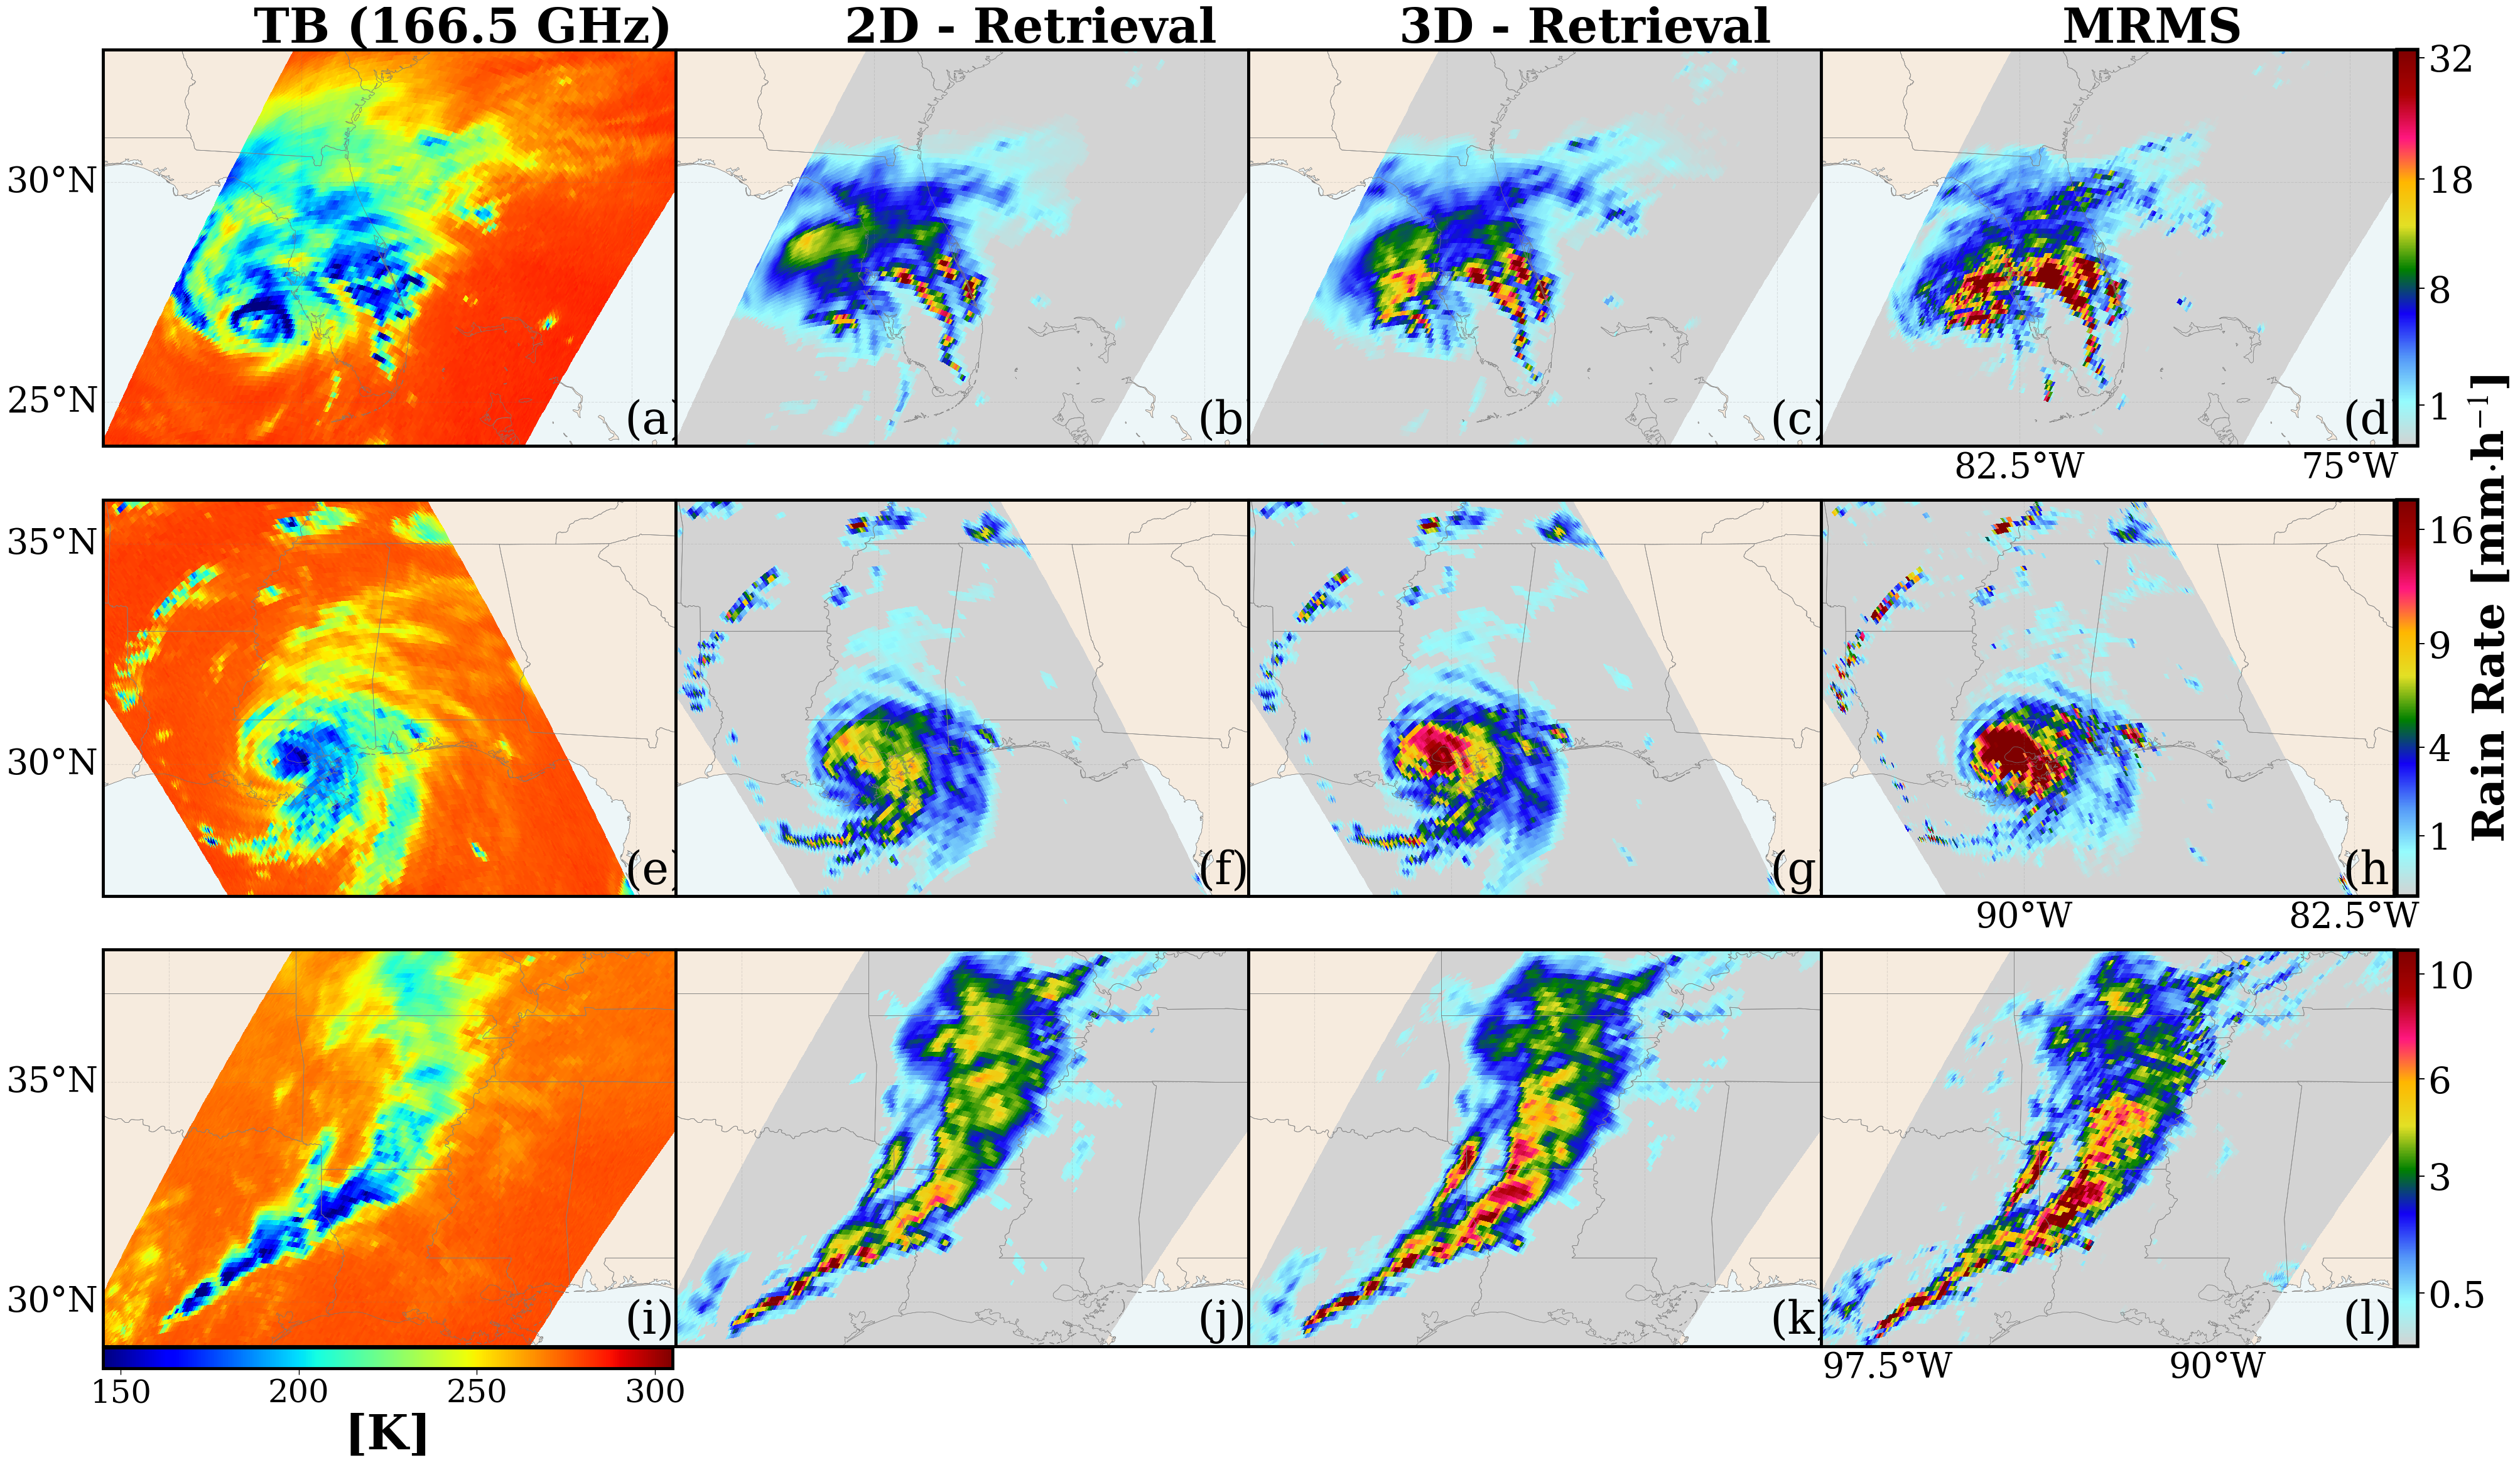

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model3  = UNet3D(in_channels=1, num_classes=2).to(device)
model3.load_state_dict(torch.load('Models/EVAL/UNet3D-Rain.pth', map_location=device))
model3.eval()

model2  = UNet(in_channels=13, num_classes=2).to(device)
model2.load_state_dict(torch.load('Models/EVAL/UNet-Rain_Conv2D.pth', map_location=device))
model2.eval()
FILES = ['Orbits/1B.GPM.GMI.TB2021.20241009-S182844-E200157.060279.V08A.hdf5',
         'Orbits/1B.GPM.GMI.TB2021.20210829-S235714-E012947.042630.V08A.hdf5',
         'Orbits/1B.GPM.GMI.TB2021.20240123-S223131-E000445.056266.V08A.hdf5']

import h5py

FINAL_DATA = []

for i in range(3):

    if i == 1:

        filename = FILES[i]
        Data = h5py.File(FILES[i], 'r')
        OFFSET = 7
        x, y = INDEX(Data['MRMS/Rate'][:])
        Lat_1 = Data['S1/Latitude'][x+OFFSET:y+221+OFFSET]
        Lon_1 = Data['S1/Longitude'][x+OFFSET:y+221+OFFSET]

        Lat_2 = Data['S2/Latitude'][x+OFFSET:y+221+OFFSET]
        Lon_2 = Data['S2/Longitude'][x+OFFSET:y+221+OFFSET]

        TB1 = Data['S1/Tb'][x+OFFSET:y+221+OFFSET]
        TB_2 = Data['S2/Tb'][x+OFFSET:y+221+OFFSET].transpose(2, 0, 1)

        TB_1 = np.zeros((0,221+221,221))

        for j in range(9):
            TB_1 = np.concatenate((TB_1,np.expand_dims(interpolate_precipitation(TB1[:,:,j], Lat_1, Lon_1, Lat_2, Lon_2, method='nearest'), axis = 0)), axis = 0)

        #Lsm = Data['ERA5/lsm'][x:y]
        #T2m = Data['ERA5/t2m'][x:y]
        Rate = Data['MRMS/Rate'][x+OFFSET:y+221+OFFSET]
        Flag = Data['MRMS/Flag'][x+OFFSET:y+221+OFFSET]

    else:

        filename = FILES[i]
        Data = h5py.File(FILES[i], 'r')

        x, y = INDEX(Data['MRMS/Rate'][:])
        Lat_1 = Data['S1/Latitude'][x-221:y]
        Lon_1 = Data['S1/Longitude'][x-221:y]

        Lat_2 = Data['S2/Latitude'][x-221:y]
        Lon_2 = Data['S2/Longitude'][x-221:y]

        TB1 = Data['S1/Tb'][x-221:y]
        TB_2 = Data['S2/Tb'][x-221:y].transpose(2, 0, 1)

        TB_1 = np.zeros((0,221+221,221))

        for j in range(9):
            TB_1 = np.concatenate((TB_1,np.expand_dims(interpolate_precipitation(TB1[:,:,j], Lat_1, Lon_1, Lat_2, Lon_2, method='nearest'), axis = 0)), axis = 0)

        #Lsm = Data['ERA5/lsm'][x:y]
        #T2m = Data['ERA5/t2m'][x:y]
        Rate = Data['MRMS/Rate'][x-221:y]
        Flag = Data['MRMS/Flag'][x-221:y]

    FINAL = np.concatenate((np.expand_dims(Lat_2,axis = 0), np.expand_dims(Lon_2,axis = 0), TB_1, TB_2, np.stack([Rate, Flag], axis=0)), axis=0)
    #np.save(f'FINAL/P#{FILES[i].split(".")[-3]}', FINAL)
    #print(f'#{i} has been done')
    raw_data = FINAL[:,:221,:].astype(np.float32)
    cls_map3, rain_rate3 = inference_3d(raw_data, model3)


    Rain_MRMS_P3_1 = rain_rate3.copy()

    Rain_MRMS_P3_1[np.where( (cls_map3 != 1))] = 0

    raw_data = FINAL[:,221:,:].astype(np.float32)
    cls_map3, rain_rate3 = inference_3d(raw_data, model3)


    Rain_MRMS_P3_2 = rain_rate3.copy()

    Rain_MRMS_P3_2[np.where( (cls_map3 != 1))] = 0

    Final_3D = np.concatenate((Rain_MRMS_P3_1, Rain_MRMS_P3_2))

    raw_data = FINAL[:,:221,:].astype(np.float32)
    cls_map2, rain_rate2 = inference_2d(raw_data, model2)


    Rain_MRMS_P2_1 = rain_rate2.copy()

    Rain_MRMS_P2_1[np.where( (cls_map2 != 1))] = 0

    raw_data = FINAL[:,221:,:].astype(np.float32)
    cls_map2, rain_rate2 = inference_2d(raw_data, model2)


    Rain_MRMS_P2_2 = rain_rate2.copy()

    Rain_MRMS_P2_2[np.where( (cls_map2 != 1))] = 0

    Final_2D = np.concatenate((Rain_MRMS_P2_1, Rain_MRMS_P2_2))



    Data = FINAL
    Flag_mapped = Data[-1]
    Rate_mapped = Data[-2]
    Rain_MRMS = Rate_mapped.copy()
    Rain_MRMS[np.where( (Flag_mapped != 1))] = 0


    Lat_g = Data[0]
    Lon_g = Data[1]%360


    GEO = [Lat_g, Lon_g]
    TB = [Data[2:-2]]
    PRE = [Final_2D, Final_3D]
    GRD = [Rain_MRMS]


    f  = [GEO,TB, PRE, GRD]

    FINAL_DATA.append(f)






import h5py

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
import cartopy.feature as cfeature
from matplotlib.patches import Circle
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle

#[GEO,TB, PRE, GRD]

# --- LaTeX removed: use serif fonts + mathtext (STIX mimics the newtx look) ---
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "stix",
})

Cmap_Rain = plt.cm.colors.LinearSegmentedColormap.from_list('custom', ['#D3D3D3', '#95FCFD', '#5497F8', '#1301F5',
 '#008000', "#E3E025", "#FFB700", "#FF167F","#AB0101", "#7F0000"])
Cmap_Snow = plt.cm.colors.LinearSegmentedColormap.from_list('custom', ["#E0E0E0", "#A9EAFE", "#00BFFF", "#0000FF", "#9400D3"])
fig = plt.figure(figsize=(48, 36))
ax = np.empty(12, dtype=object)
gl = np.empty(12, dtype=object)

for i in range(12):
    ax[i] = plt.subplot2grid((3, 4), (i // 4, i % 4), projection=ccrs.PlateCarree())

for i in range(0,12):
    gl[i] = ax[i].gridlines(draw_labels=True,
                        xlocs=np.arange(-180, 181, 7.5),  # Longitude every 30°
                        ylocs=np.arange(-90, 91, 5),
                        color='gray', alpha=0.2, linestyle='--')    # Latitude every 30°
    gl[i].right_labels = False
    gl[i].bottom_labels = False
    gl[i].top_labels = False
    gl[i].left_labels = False

#gl[0].left_labels = True
#gl[-1].bottom_labels = True


for i in range(12):
    for spine in ax[i].spines.values():
        spine.set_linewidth(3.5)


regional_extent1 = [-87, -74, 24,33]
regional_extent2 = [-94.6, -81.6, 27,36]
regional_extent3 = [-99, -86, 29,38]
regional_extent = [regional_extent1, regional_extent2, regional_extent3]
for i in range(3):
    for j in range(4):
        ax[i*4+j].set_extent(regional_extent[i], crs=ccrs.PlateCarree())

        # added land-ocean background
        ax[i*4+j].set_facecolor("#EDF6F8")
        ax[i*4+j].add_feature(cfeature.LAND, facecolor="#F6EBDE", edgecolor="none", zorder=0)

        ax[i*4+j].add_feature(cfeature.COASTLINE, linewidth=0.1)
        ax[i*4+j].add_feature(cfeature.BORDERS, linewidth=0.7, linestyle=':')
        ax[i*4+j].add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')  # Add this line

for i in range(12):
    ax[i].text(0.91, 0.12, '(' + chr(97 + i) + ')', transform=ax[i].transAxes, fontsize=52, va='top')

VMAX = [33, 18, 11]

power = 0.65

rain_ticks = [[1,8, 18, 32], [1, 4, 9, 16], [0.5, 3, 6, 10]]
for k in range(3):

    mesh1 = ax[0+4*k].pcolormesh(FINAL_DATA[k][0][-1], FINAL_DATA[k][0][0], FINAL_DATA[k][1][0][9],
                        transform=ccrs.PlateCarree(),
                        cmap = 'jet',
                        vmin =145,
                        vmax =305)

    mesh2 = ax[1+4*k].pcolormesh(FINAL_DATA[k][0][-1], FINAL_DATA[k][0][0], FINAL_DATA[k][2][0]**power,
                        transform=ccrs.PlateCarree(),
                            cmap = Cmap_Rain,
                            vmin =0,
                            vmax =VMAX[k]**power)

    mesh2 = ax[2+4*k].pcolormesh(FINAL_DATA[k][0][-1], FINAL_DATA[k][0][0], FINAL_DATA[k][2][1]**power,
                        transform=ccrs.PlateCarree(),
                            cmap = Cmap_Rain,
                            vmin =0,
                            vmax =VMAX[k]**power)

    mesh2 = ax[3+4*k].pcolormesh(FINAL_DATA[k][0][-1], FINAL_DATA[k][0][0], FINAL_DATA[k][3][0]**power,
                        transform=ccrs.PlateCarree(),
                            cmap = Cmap_Rain,
                            vmin =0,
                            vmax =VMAX[k]**power)

    cbar1_ax = fig.add_axes([0.8810, 0.2132 + (k-2)*(-0.19913), 0.007, 0.17521])
    cbar1 = fig.colorbar(mesh2, cax=cbar1_ax)

    rain_ticks_original = rain_ticks[k]
    rain_ticks_transformed = [val ** power for val in rain_ticks_original]

    cbar1.set_ticks(rain_ticks_transformed)
    cbar1.ax.set_yticklabels(rain_ticks_original)
    cbar1.ax.tick_params(labelsize=42, length=8, width=1.4)


    for spine in cbar1.ax.spines.values():
        spine.set_linewidth(4)




    for spine in cbar1.ax.spines.values():
        spine.set_linewidth(4)



for t in range(3):
    gl[0+t*4].right_labels = False
    gl[0+t*4].bottom_labels = False
    gl[0+t*4].top_labels = False
    gl[0+t*4].left_labels = True
    gl[0+t*4].xlabel_style = {'size': 40}
    gl[0+t*4].ylabel_style = {'size': 40}

    gl[3+t*4].right_labels = False
    gl[3+t*4].bottom_labels = True
    gl[3+t*4].top_labels = False
    gl[3+t*4].left_labels = False
    gl[3+t*4].xlabel_style = {'size': 40}
    gl[3+t*4].ylabel_style = {'size': 40}


fig.text(0.17, 0.79, 'TB (166.5 GHz)',
         fontsize=55, fontweight='bold')

fig.text(0.366, 0.79, '2D - Retrieval',
         fontsize=55, fontweight='bold')

fig.text(0.55, 0.79, '3D - Retrieval',
         fontsize=55, fontweight='bold')

fig.text(0.77, 0.79, 'MRMS',
         fontsize=55, fontweight='bold')



for spine in cbar1.ax.spines.values():
    spine.set_linewidth(4)



cbar3_ax = fig.add_axes([0.12, 0.2035, 0.189, 0.009])  # [left, bottom, width, height]
cbar3 = fig.colorbar(mesh1, cax=cbar3_ax,  orientation='horizontal')
cbar3.set_ticks(np.arange(150, 310, 50))
cbar3.set_label('[K]', fontsize=55, fontweight='bold')
cbar3.ax.tick_params(labelsize=37, length=7.5, width =1)


for spine in cbar3.ax.spines.values():
    spine.set_linewidth(3.5)

plt.subplots_adjust(
    left=0.12,      # Left margin
    bottom=0.12,    # Bottom margin
    right=0.88,     # Right margin
    top=0.88,       # Top margin
    wspace=0,     # Width spacing between subplots
    hspace=-0.45  # Height spacing between subplots (increase if needed)
)


fig.text(
    0.905,
    0.44,
    r'Rain Rate [mm$\cdot$h$^{-1}$]',
    fontsize=50,
    fontweight='bold',
    rotation=90
)
#plt.savefig("Fig03.png", dpi=300, bbox_inches="tight")